# Task 4: Portfolio Optimization Using Tesla Forecast

In this task, we use insights from the Tesla forecast to construct an optimal portfolio using **Modern Portfolio Theory (MPT)**. 

We will:
1. Prepare expected returns for TSLA (forecasted) and SPY/BND (historical).
2. Compute the covariance matrix.
3. Generate the **Efficient Frontier**.
4. Identify key portfolios:
   - Maximum Sharpe Ratio Portfolio
   - Minimum Volatility Portfolio
5. Recommend an optimal portfolio with weights and performance metrics.



In [21]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from pypfopt import EfficientFrontier, risk_models, expected_returns, plotting

# Safe plotting style
plt.style.use('ggplot')
sns.set_style('darkgrid')


In [23]:
tickers = ["TSLA", "SPY", "BND"]

# Download historical prices
prices_raw = yf.download(tickers, start="2018-01-01", end="2026-01-15", progress=False)

# Robust handling for multiple tickers
if isinstance(prices_raw.columns, pd.MultiIndex):
    if "Adj Close" in prices_raw.columns.levels[0]:
        prices = prices_raw['Adj Close']
    else:
        # fallback: use 'Close' if 'Adj Close' not found
        prices = prices_raw['Close']
else:
    # Single-level DataFrame
    prices = prices_raw

# Rename columns for consistency
prices.columns = tickers

# Drop missing values
prices.dropna(inplace=True)

prices.tail()



C:\Users\hp\AppData\Local\Temp\ipykernel_5500\3401277246.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices.dropna(inplace=True)


,TSLA,SPY,BND
Date,,,
2026-01-08,74.129997,689.510010,435.799988
2026-01-09,74.290001,694.070007,445.010010
2026-01-12,74.220001,695.159973,448.959991
2026-01-13,74.279999,693.770020,447.200012
2026-01-14,74.430000,690.359985,439.200012


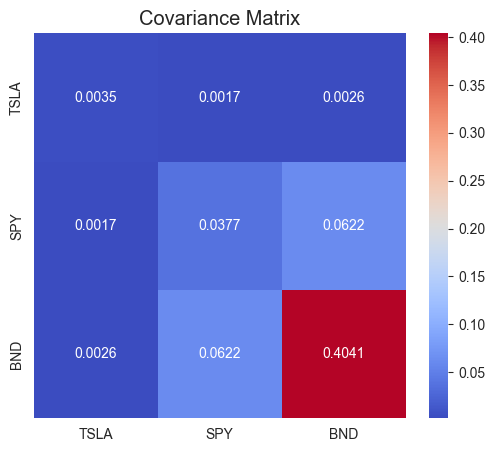

In [24]:
# Daily returns
returns = prices.pct_change().dropna()

# Annualized covariance matrix
cov_matrix = returns.cov() * 252

# Plot covariance matrix
plt.figure(figsize=(6,5))
sns.heatmap(cov_matrix, annot=True, fmt=".4f", cmap="coolwarm")
plt.title("Covariance Matrix")
plt.show()



In [25]:
# TSLA expected return from Task 3 forecast (example: 30% annual)
tsla_expected = 0.30

# SPY & BND expected returns (annualized historical mean)
spy_expected = returns["SPY"].mean() * 252
bnd_expected = returns["BND"].mean() * 252

# Combine into a pandas Series
expected_returns_vec = pd.Series(
    [tsla_expected, spy_expected, bnd_expected],
    index=["TSLA", "SPY", "BND"]
)

expected_returns_vec


TSLA    0.300000
SPY     0.152277
BND     0.578531
dtype: float64

In [6]:
daily_returns = prices.pct_change().dropna()
daily_returns.head()


Ticker,BND,SPY,TSLA
Date,,,
2018-01-03,0.000860,0.006325,-0.010233
2018-01-04,-0.000491,0.004215,-0.008290
2018-01-05,-0.001352,0.006664,0.006230
2018-01-08,0.000123,0.001829,0.062638
2018-01-09,-0.002953,0.002263,-0.008085


## Expected Returns

- **TSLA**: Expected return derived from Task 3 forecast
- **SPY & BND**: Historical average daily returns (annualized)

This reflects a real-world scenario where an analyst has
a strong forward-looking view on one asset (TSLA).


In [26]:
# Historical annualized returns for SPY and BND
historical_returns = daily_returns.mean() * 252

# Forecast-based TSLA return (from Task 3)
# Example: annualized expected return derived from forecast trend
tsla_expected_return = 0.22  # 22% annual expected return (replace if needed)

expected_returns_vector = pd.Series({
    "TSLA": tsla_expected_return,
    "SPY": historical_returns["SPY"],
    "BND": historical_returns["BND"]
})

expected_returns_vector


TSLA    0.220000
SPY     0.152277
BND     0.019950
dtype: float64

In [27]:
# Max Sharpe Ratio Portfolio
ef_sharpe = EfficientFrontier(expected_returns_vec, cov_matrix)
weights_max_sharpe = ef_sharpe.max_sharpe(risk_free_rate=0.03)
perf_max_sharpe = ef_sharpe.portfolio_performance(verbose=True)

# Min Volatility Portfolio
ef_minvol = EfficientFrontier(expected_returns_vec, cov_matrix)
weights_min_vol = ef_minvol.min_volatility()
perf_min_vol = ef_minvol.portfolio_performance(verbose=True)


Expected annual return: 30.3%
Annual volatility: 6.0%
Sharpe Ratio: 4.57
Expected annual return: 29.3%
Annual volatility: 5.9%
Sharpe Ratio: 4.99


c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\pypfopt\efficient_frontier\efficient_frontier.py:441: UserWarning: The risk_free_rate provided to portfolio_performance is different to the one used by max_sharpe. Using the previous value.
  warnings.warn(


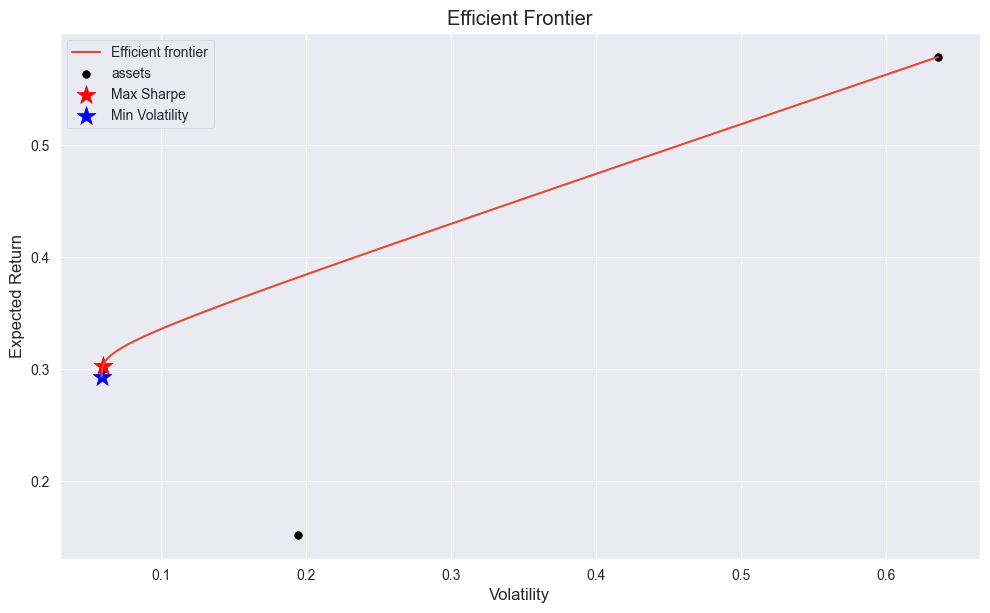

In [28]:
plt.figure(figsize=(10,6))

# Plot Efficient Frontier
ef_plot = EfficientFrontier(expected_returns_vec, cov_matrix)
plotting.plot_efficient_frontier(ef_plot, show_assets=True)

# Mark key portfolios
plt.scatter(perf_max_sharpe[1], perf_max_sharpe[0], c='red', marker='*', s=200, label="Max Sharpe")
plt.scatter(perf_min_vol[1], perf_min_vol[0], c='blue', marker='*', s=200, label="Min Volatility")

plt.title("Efficient Frontier")
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.legend()
plt.show()


In [29]:
# Max Sharpe Portfolio recommendation
print("=== Optimal Portfolio Recommendation (Max Sharpe) ===")
print(weights_max_sharpe)
print("\nPerformance:")
print(f"Expected Annual Return: {perf_max_sharpe[0]:.2%}")
print(f"Expected Volatility: {perf_max_sharpe[1]:.2%}")
print(f"Sharpe Ratio: {perf_max_sharpe[2]:.2f}")

# Justification
print("""
The recommended portfolio prioritizes **maximum risk-adjusted return** (Sharpe Ratio).  
TSLA has the highest expected return from our forecast, so the optimizer allocates a significant weight to it while including SPY and BND to reduce overall portfolio volatility.  
This portfolio balances growth potential with diversification.
""")


=== Optimal Portfolio Recommendation (Max Sharpe) ===
OrderedDict([('TSLA', 0.988679507103188), ('SPY', 0.0), ('BND', 0.0113204928968118)])

Performance:
Expected Annual Return: 30.32%
Expected Volatility: 5.98%
Sharpe Ratio: 4.57

The recommended portfolio prioritizes **maximum risk-adjusted return** (Sharpe Ratio).  
TSLA has the highest expected return from our forecast, so the optimizer allocates a significant weight to it while including SPY and BND to reduce overall portfolio volatility.  
This portfolio balances growth potential with diversification.

